# Solving the Gouy--Chapman model
We seek to solve the Gouy–Chapman model of the symmetric electrolyte 1:1 model:
$$
\boxed{
\begin{aligned}
    &\varepsilon_{0}\varepsilon_{r}\frac{\text{d}^{2}\phi}{\text{d}x^{2} } &= -\frac{e_{0} N_{\mathrm{A}} c_{\mathrm{b}}}{2}\sinh\left(\frac{e_{0}\phi}{k_{\mathrm{B}}T}\right),  &0 < x < +\infty  \\
  \phi\left(x\right) &= \phi_{\text{M}} - \phi_{\text{pzc}},  &x = 0 \\ 
  \phi\left(x\right) &= 0,     &x = +\infty
\end{aligned}
}
$$



# Parametric setup  ###

### The following lines of codes set up the paramters and fundamental constants of the Gouy--Chapman--Stern model



In [1]:
from dataclasses import dataclass
import math

# Fundamental constants
e = 1.602176634e-19      # C
kB = 1.380649e-23        # J/K
eps0 = 8.8541878128e-12  # F/m
NA = 6.02214076e23       # 1/mol

@dataclass
class GC_SI_Params:
    eps_S: float = 78.5     # Relative permittivity of the bulk (relative)
    c_bulk: float = 1.0   # Debye length (m)
    T: float = 298.15       # Temperature (K)


def compute_lambda_D(p: GC_SI_Params) -> float:
    return math.sqrt(
        p.eps_S * eps0 * kB * p.T /
        (2.0 * e**2 * NA * p.c_bulk)
    )

def validate_params_si(p: GC_SI_Params) -> None:
    if p.T <= 0:
        raise ValueError("Temperature must be > 0 K")
    if p.eps_S <= 1:
        raise ValueError("Relative permittivity must be > 1")
    if p.c_bulk <= 0:
        raise ValueError("Bulk concentration must be > 0")

# Solutions to the Gouy–Chapman model

The solutions are proivded by
$$
\begin{aligned}
    \phi^{\left(\mathrm{GC}\right)}\left(x\right) &= 4 k_{\text{B}}T e_{0}^{-1}\,\text{arctanh}\left(\tanh\left(\frac{e_{0}\left(\phi_{\text{M}} - \phi_{\text{pzc}}\right)  }{4k_{\text{B}}T }\right)\exp\left(-\lambda_{\text{D}}^{-1}\mathbf{x} \right) \right) \\
    c_{-}^{\left(\mathrm{GC}\right)}\left(x\right) &= c_{\mathrm{b}}\, \exp\left(\frac{e_{0} \phi\left(x\right) }{k_{\mathrm{B}} T }\right) \\
    c_{+}^{\left(\mathrm{GC}\right)}\left(x\right) &= c_{\mathrm{b}}\, \exp\left(-\frac{e_{0} \phi\left(x\right) }{k_{\mathrm{B}} T }\right)  \\
    \sigma_{\mathrm{free}}^{\left(\mathrm{GC}\right)} &= \sqrt{8k_{\mathrm{B}}T \varepsilon_{0}\varepsilon_{r} c_{\mathrm{b}} }\sinh\left(\frac{e_{0}\left(\phi_{\mathrm{M}} - \phi_{\mathrm{pzc}}\right)}{2 k_{\mathrm{B}} T }\right) \\
    C_{\mathrm{dl}}^{\left(\mathrm{GC}\right)} &= \varepsilon_{0}\varepsilon_{r}\lambda_{\mathrm{D}}^{-1}\cosh\left(\frac{e_{0} \left(\phi_{\mathrm{M}} - \phi_{\mathrm{pzc}}\right) }{2k_{\mathrm{B}}T }\right)
\end{aligned}
$$
with $$\lambda_{\text{D}}^{-1} = \left(\frac{2e_{0}^{2} n_{0} }{\varepsilon_{0}\varepsilon_{r} k_{\text{B}}T  }\right)^{\frac{1}{2}}$$ being the inverse Debye length.

In [2]:
import numpy as np


def U_GC(x, p: GC_SI_Params, psi0: float):
    lam_D = compute_lambda_D(p)
    U0 = e * psi0 / (kB * p.T)
    x = np.asarray(x)

    y = np.exp(-x / lam_D) * np.tanh(U0 / 4.0)
    return 4.0 * np.arctanh(y)

def psi_GC(x, p: GC_SI_Params, psi0: float):
    """
    Electric potential psi(x) in volts.
    """
    return (kB * p.T / e) * U_GC(x, p, psi0)

def cation_concentration(p, psi):
    U = e * np.asarray(psi) / (kB * p.T)
    return p.c_bulk * np.exp(-U)

def anion_concentration(p, psi):
    U = e * np.asarray(psi) / (kB * p.T)
    return p.c_bulk * np.exp(+U)


def surface_free_charge(p, psi):
    prefactor = np.sqrt(8.0 * p.eps_S * eps0 * NA * kB * p.T * p.c_bulk)
    arg = e * psi / (2 * kB * p.T)
    return prefactor * np.sinh(arg)

def C_GC(p, psi):
    lam_D = compute_lambda_D(p)
    arg = e * psi / (2 * kB * p.T)
    return (p.eps_S * eps0 / lam_D) * np.cosh(arg)

In [3]:
def make_params_and_psi0_from_input(input_name, value, base_params, base_psi0):
    if input_name == "Concentration":
        p = GC_SI_Params(
            eps_S=base_params.eps_S,
            c_bulk=value,
            T=base_params.T
        )
        return p, base_psi0

    elif input_name == "Temperature":
        p = GC_SI_Params(
            eps_S=base_params.eps_S,
            c_bulk=base_params.c_bulk,
            T=value
        )
        return p, base_psi0

    elif input_name == "Dielectric constant":
        p = GC_SI_Params(
            eps_S=value,
            c_bulk=base_params.c_bulk,
            T=base_params.T
        )
        return p, base_psi0

    elif input_name == "Applied Potential":
        return base_params, value

    else:
        raise ValueError("Invalid input_name")

# Define plotting setup from parameter list

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def plot_gc_profiles_sigma_cap(
    input_name,
    input_values,
    psi0,
    x_max_nm,
    npts,
    base_concentration,
    base_temperature,
    base_dielectric,
    phi_min,
    phi_max,
    sigma_npts=200
):
    if phi_min >= phi_max:
        raise ValueError("phi_min must be smaller than phi_max")

    base_params = GC_SI_Params(
        eps_S=base_dielectric,
        c_bulk=base_concentration,
        T=base_temperature
    )

    x_nm = np.linspace(0.01, x_max_nm, npts)
    x_m = x_nm * 1e-9
    phi_grid = np.linspace(phi_min, phi_max, sigma_npts)

    fig = plt.figure(figsize=(11, 7), constrained_layout=True)
    gs = fig.add_gridspec(2, 6)

    ax1 = fig.add_subplot(gs[0, 0:2])
    ax2 = fig.add_subplot(gs[0, 2:4])
    ax3 = fig.add_subplot(gs[0, 4:6])
    ax4 = fig.add_subplot(gs[1, 0:3])
    ax5 = fig.add_subplot(gs[1, 3:6])

    sweeping_applied_potential = (input_name == "Applied Potential")

    ncurves = len(input_values)
    if ncurves == 1:
        tvals = np.array([0.0])
    else:
        tvals = np.linspace(0.0, 1.0, ncurves, endpoint=False)

    def blend_with_white(rgb, strength=0.65):
        rgb = np.array(rgb[:3], dtype=float)
        return tuple((1 - strength) * np.ones(3) + strength * rgb)

    def mix(c1, c2, t):
        c1 = np.array(c1, dtype=float)
        c2 = np.array(c2, dtype=float)
        return tuple((1 - t) * c1 + t * c2)

    # Electric potential: neutral dark-gray ramp
    start_gray = np.array([0.15, 0.15, 0.15])
    end_gray   = np.array([0.65, 0.65, 0.65])

    if ncurves == 1:
        potential_colors = [tuple(start_gray)]
    else:
        potential_colors = [
            mix(start_gray, end_gray, i / (ncurves - 1))
            for i in range(ncurves)
        ]

    # Other panels: hue-specific gradients
    cation_colors = [
        blend_with_white((1.0, 0.0, 0.0, 1.0), 0.25 + 0.65 * t) for t in tvals
    ]
    anion_colors = [
        blend_with_white((0.0, 0.0, 1.0, 1.0), 0.25 + 0.65 * t) for t in tvals
    ]
    sigma_colors = [
        blend_with_white((0.0, 0.55, 0.0, 1.0), 0.25 + 0.65 * t) for t in tvals
    ]
    cap_colors = [
        blend_with_white((0.5, 0.0, 0.5, 1.0), 0.25 + 0.65 * t) for t in tvals
    ]

    for i, val in enumerate(input_values):
        p, psi0_this = make_params_and_psi0_from_input(
            input_name=input_name,
            value=val,
            base_params=base_params,
            base_psi0=psi0
        )

        validate_params_si(p)

        psi_profile = psi_GC(x_m, p, psi0_this)
        ncat = cation_concentration(p, psi_profile)
        nani = anion_concentration(p, psi_profile)

        if input_name == "Concentration":
            label = f"{val:g} mM"
        elif input_name == "Temperature":
            label = f"{val:g} K"
        elif input_name == "Applied Potential":
            label = f"{val:g} V"
        elif input_name == "Dielectric constant":
            label = rf"$\varepsilon_r = {val:g}$"
        else:
            label = f"{input_name} = {val:g}"

        ax1.plot(x_nm, psi_profile, label=label, color=potential_colors[i], lw=2.5)
        ax2.plot(x_nm, ncat, label=label, color=cation_colors[i], lw=2)
        ax3.plot(x_nm, nani, label=label, color=anion_colors[i], lw=2)

        sigma_vals = surface_free_charge(p, phi_grid)
        cap_vals = C_GC(p, phi_grid)

        C_PER_M2_TO_UC_PER_CM2 = 100.0
        F_PER_M2_TO_UF_PER_CM2 = 100.0

        sigma_vals = C_PER_M2_TO_UC_PER_CM2 * sigma_vals
        cap_vals = F_PER_M2_TO_UF_PER_CM2 * cap_vals

        ax4.plot(phi_grid, sigma_vals, label=label, color=sigma_colors[i], lw=2)
        ax5.plot(phi_grid, cap_vals, label=label, color=cap_colors[i], lw=2)

    ax1.set_title("Electric potential")
    ax1.set_xlabel("Distance from surface (nm)", fontsize=14)
    ax1.set_ylabel("Electric potential (V)", fontsize=14)

    ax2.set_title("Cation density")
    ax2.set_xlabel("Distance from surface (nm)", fontsize=14)
    ax2.set_ylabel("Cation density (mol/m$^3$)", fontsize=14)

    ax3.set_title("Anion density")
    ax3.set_xlabel("Distance from surface (nm)", fontsize=14)
    ax3.set_ylabel("Anion density (mol/m$^3$)", fontsize=14)

    ax4.set_title("Surface free charge density")
    ax4.set_xlabel(r"$\phi_M - \phi_{pzc}$ (V)", fontsize=16)
    ax4.set_ylabel(r"Surface Free Charge Density ($\mu$C/cm$^2$)")

    ax5.set_title("Double layer capacitance")
    ax5.set_xlabel(r"$\phi_M - \phi_{pzc}$ (V)", fontsize=16)
    ax5.set_ylabel(r"Double layer Capacitance ($\mu$F/cm$^2$)")

    for ax in [ax1, ax2, ax3, ax4, ax5]:
        ax.grid(True)

    ax1.legend(fontsize=9)
    ax2.legend(fontsize=9)
    ax3.legend(fontsize=9)

    if not sweeping_applied_potential:
        ax4.legend(fontsize=9)
        ax5.legend(fontsize=9)

    return fig

# Define Error function

In [5]:
import ipywidgets as widgets

def show_error(message):
    display(widgets.HTML(
        f"""
        <div style="
            color: #842029;
            background-color: #f8d7da;
            border: 1px solid #f5c2c7;
            border-radius: 6px;
            padding: 10px 12px;
            margin-top: 8px;
            font-weight: 500;
        ">
            {message}
        </div>
        """
    ))

# Make User Interface

In [6]:
import ipywidgets as widgets
from IPython.display import display
import numpy as np

LABEL_WIDTH = "170px"
BOX_WIDTH = "140px"

def make_row(label_html, widget, fontsize="16px"):
    widget.layout = widgets.Layout(width=BOX_WIDTH)

    label = widgets.HTML(
        value=f"""
        <span style="font-size:{fontsize}; line-height:1.2;">
            {label_html}
        </span>
        """,
        layout=widgets.Layout(width=LABEL_WIDTH)
    )

    return widgets.HBox(
        [label, widget],
        layout=widgets.Layout(align_items="center")
    )

input_dropdown = widgets.Dropdown(
    options=["Concentration", "Temperature", "Dielectric constant", "Applied Potential"],
    value="Concentration",
    layout=widgets.Layout(width=BOX_WIDTH)
)
input_row = make_row("Input:", input_dropdown)

values_text = widgets.Text(
    value="10, 20, 40",
    placeholder="comma-separated values"
)
values_row = make_row("Sweep:", values_text)

psi0_box = widgets.FloatText(
    value=0.1
)
psi0_row = make_row("φ<sub>M</sub> − φ<sub>pzc</sub> (V)", psi0_box)

phi_min_box = widgets.FloatText(
    value=-0.3
)
phi_min_row = make_row("φ<sub>min</sub> (V):", phi_min_box)

phi_max_box = widgets.FloatText(
    value=0.3
)
phi_max_row = make_row("φ<sub>max</sub> (V):", phi_max_box)

xmax_box = widgets.FloatText(
    value=5.0
)
xmax_row = make_row("x<sub>max</sub>  (nm):", xmax_box)

base_c_box = widgets.FloatText(
    value=10.0
)
base_c_row = make_row("base c:", base_c_box)

base_T_box = widgets.FloatText(
    value=298.15
)
base_T_row = make_row("base T:", base_T_box)

base_eps_box = widgets.FloatText(
    value=78.5
)
base_eps_row = make_row("base ε<sub>r</sub>:", base_eps_box)

plot_button = widgets.Button(
    description="Plot",
    button_style="success",
    layout=widgets.Layout(width="120px")
)

plot_row = widgets.HBox(
    [widgets.HTML(layout=widgets.Layout(width=LABEL_WIDTH)), plot_button]
)

out = widgets.Output(
    layout=widgets.Layout(
        width="auto",
        border="none"
    )
)

npts = 200

base_header = widgets.HTML(
    """
    <div style="
        font-size:14px;
        font-weight:600;
        margin-top:8px;
        margin-bottom:4px;
    ">
        Base values used for parameters not being swept:
    </div>
    """
)

def update_visible_base_inputs(*args):
    swept = input_dropdown.value

    base_c_row.layout.display = "" if swept != "Concentration" else "none"
    base_T_row.layout.display = "" if swept != "Temperature" else "none"
    base_eps_row.layout.display = "" if swept != "Dielectric constant" else "none"
    psi0_row.layout.display = "none" if swept == "Applied Potential" else ""


def on_plot_clicked(b):
    out.clear_output(wait=True)
    plt.close("all")

    try:
        input_values = np.array(
            [float(v.strip()) for v in values_text.value.split(",") if v.strip()]
        )

        if input_values.size == 0:
            raise ValueError("Please enter at least one sweep value.")
        if xmax_box.value <= 0:
            raise ValueError("x max must be > 0 nm.")
        if npts < 2:
            raise ValueError("Points must be at least 2.")
        if phi_min_box.value >= phi_max_box.value:
            raise ValueError("phi min must be smaller than phi max.")

        fig = plot_gc_profiles_sigma_cap(
            input_name=input_dropdown.value,
            input_values=input_values,
            psi0=psi0_box.value,
            x_max_nm=xmax_box.value,
            npts=npts,
            base_concentration=base_c_box.value,
            base_temperature=base_T_box.value,
            base_dielectric=base_eps_box.value,
            phi_min=phi_min_box.value,
            phi_max=phi_max_box.value,
            sigma_npts=npts
        )

        with out:
            display(fig)

        plt.close(fig)

    except ValueError as err:
        plt.close("all")
        out.clear_output(wait=True)
        with out:
            show_error(f"Invalid input: {err}")

    except Exception as err:
        plt.close("all")
        out.clear_output(wait=True)
        with out:
            show_error(f"Unexpected error: {err}")

try:
    input_dropdown.unobserve(update_visible_base_inputs, names="value")
except Exception:
    pass

input_dropdown.observe(update_visible_base_inputs, names="value")

plot_button.on_click(on_plot_clicked, remove=True)
plot_button.on_click(on_plot_clicked)

update_visible_base_inputs()


controls = widgets.VBox(
    [
        input_row,
        values_row,
        psi0_row,
        phi_min_row,
        phi_max_row,
        xmax_row,
        base_header,
        base_c_row,
        base_T_row,
        base_eps_row,
        plot_row,
    ],
    layout=widgets.Layout(
        width="340px",
        min_width="340px"
    )
)

output_panel = widgets.Box(
    [out],
    layout=widgets.Layout(
        flex="1 1 0%",
        width="auto"
    )
)

ui = widgets.HBox(
    [controls, output_panel],
    layout=widgets.Layout(
        width="100%",
        align_items="flex-start"
    )
)

display(ui)

# Compare with experimental data


Source: 
### Valette, G. (1982). Double layer on silver single crystal electrodes in contact with electrolytes having anions which are slightly specifically adsorbed: Part II. The (100) face. Journal of Electroanalytical Chemistry and Interfacial Electrochemistry, 138(1), 37-54

### Fig. 3 

# Read the data

In [7]:
from pathlib import Path

VALETTE_FILES = {
    5.0: "Valette1982_5mM.txt",
    10.0: "Valette1982_10mM.txt",
    20.0: "Valette1982_20mM.txt",
    40.0: "Valette1982_40mM.txt",
    100.0: "Valette1982_100mM.txt",
}

def load_valette_txt(filepath):
    """
    Read a Valette 1982 capacitance file with two numeric columns:
        E (S.C.E.) / V     C / μF cm²

    Returns
    -------
    E : np.ndarray
        Potential in V vs S.C.E.
    C : np.ndarray
        Capacitance in μF/cm^2
    """
    E_vals = []
    C_vals = []

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue
            if line.startswith("%"):
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            E_vals.append(float(parts[0]))
            C_vals.append(float(parts[1]))

    if not E_vals:
        raise ValueError(f"No numeric data found in {filepath}")

    return np.array(E_vals, dtype=float), np.array(C_vals, dtype=float)

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "Valette1982"

def load_all_valette_data():
    data = {}
    for conc_mM, filename in VALETTE_FILES.items():
        filepath = DATA_DIR / filename

        if filepath.exists():
            E, C = load_valette_txt(filepath)
            data[conc_mM] = {"E": E, "C": C}
        else:
            print(f"Missing file: {filepath}")

    return data


VALETTE_DATA = load_all_valette_data()

# Plot Experimental and Gouy-Chapman together

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def validate_params_si(p):
    if p.T <= 0:
        raise ValueError("Temperature must be > 0 K.")
    if p.eps_S <= 0:
        raise ValueError("Relative permittivity must be > 0.")
    if p.c_bulk <= 0:
        raise ValueError("Concentration must be > 0.")

def make_params_from_input(input_name, value, base_concentration, base_temperature, base_dielectric):
    c = base_concentration
    T = base_temperature
    eps_r = base_dielectric

    if input_name == "Concentration":
        c = value
    elif input_name == "Temperature":
        T = value
    elif input_name == "Dielectric constant":
        eps_r = value
    else:
        raise ValueError(f"Unsupported input_name: {input_name}")

    p = GC_SI_Params(
        eps_S=eps_r,
        c_bulk=c,
        T=T
    )
    validate_params_si(p)
    return p

def maybe_overlay_valette(ax, concentration_mM, label_suffix=""):
    conc_key = float(concentration_mM)
    if conc_key in VALETTE_DATA:
        data = VALETTE_DATA[conc_key]
        ax.scatter(
            data["E"],
            data["C"],
            s=28,
            marker="o",
            label=f"Valette 1982 ({conc_key:g} mM){label_suffix}"
        )

def plot_gc_capacitance_only(
    input_name,
    input_values,
    base_concentration,
    base_temperature,
    base_dielectric,
    phi_pzc,
    E_min,
    E_max,
    npts=300
):
    if E_min >= E_max:
        raise ValueError("E min must be smaller than E max.")

    E_grid = np.linspace(E_min, E_max, npts)

    fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)

    # Elegant sequential palette for model curves
    cmap = plt.cm.magma_r
    ncurves = len(input_values)

    if ncurves == 1:
        colors = [cmap(0.65)]
    else:
        colors = [cmap(t) for t in np.linspace(0.15, 0.90, ncurves)]

    for i, val in enumerate(input_values):
        p = make_params_from_input(
            input_name=input_name,
            value=val,
            base_concentration=base_concentration,
            base_temperature=base_temperature,
            base_dielectric=base_dielectric
        )

        phi_model = E_grid - phi_pzc
        cap_vals = 100.0 * C_GC(p, phi_model)

        if input_name == "Concentration":
            label = f"{val:g} mM"
            conc_key = float(val)
        else:
            label = f"{input_name} = {val:g}"
            conc_key = float(base_concentration)

        color = colors[i]

        # --- MODEL CURVE ---
        ax.plot(
            E_grid,
            cap_vals,
            linewidth=2.6,
            color=color,
            label=label,
            solid_capstyle="round"
        )

        # --- VALETTE DATA (same color, styled) ---
        if conc_key in VALETTE_DATA:
            data = VALETTE_DATA[conc_key]

            # slightly darker version of the same color
            darker = tuple(np.clip(np.array(color[:3]) * 0.7, 0, 1))

            ax.scatter(
                data["E"],
                data["C"],
                s=36,
                marker="o",
                facecolor=darker,
                edgecolor="white",
                linewidth=0.7,
                alpha=0.95,
                zorder=3,
                label=f"Valette 1982 ({conc_key:g} mM)"
            )

    ax.set_title("Double-layer capacitance with Valette 1982", fontsize=24, pad=14)
    ax.set_xlabel(r"$\phi_M$ (V)", fontsize=18)
    ax.set_ylabel(r"Double layer Capacitance ($\mu$F/cm$^2$)", fontsize=16)

    # Soft styling
    ax.grid(True, alpha=0.22, linewidth=0.8)
    ax.set_axisbelow(True)

    # Lighten top/right spines for a cleaner look
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)

    ax.tick_params(axis="both", labelsize=12)

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(
            fontsize=9,
            frameon=True,
            fancybox=True,
            framealpha=0.92,
            edgecolor="0.85"
        )

    return fig

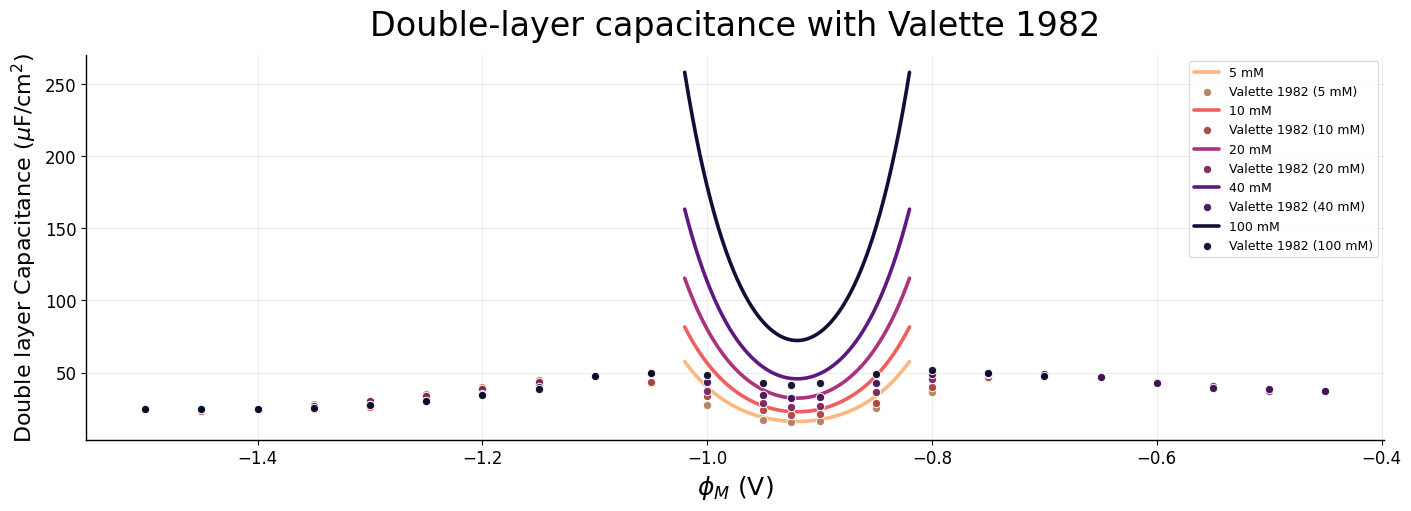

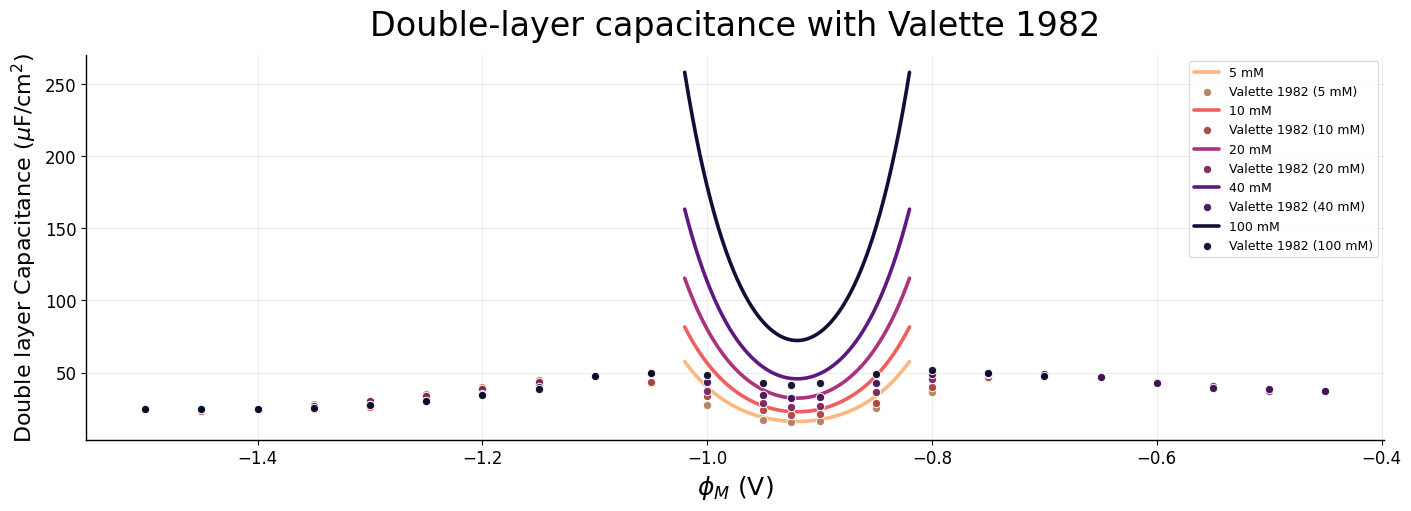

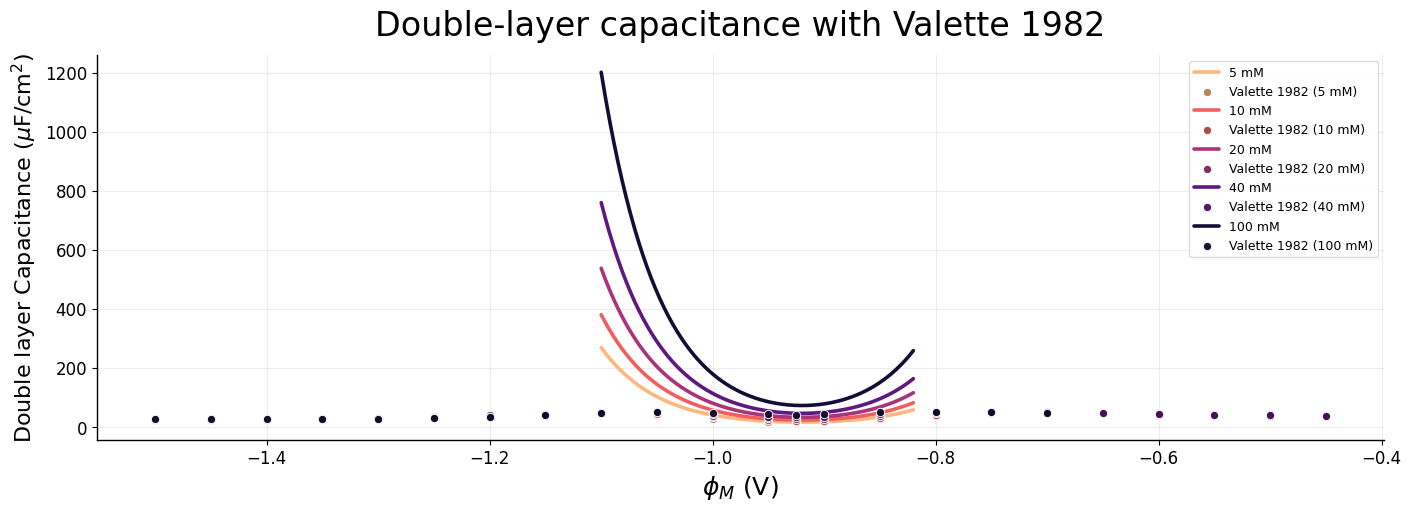

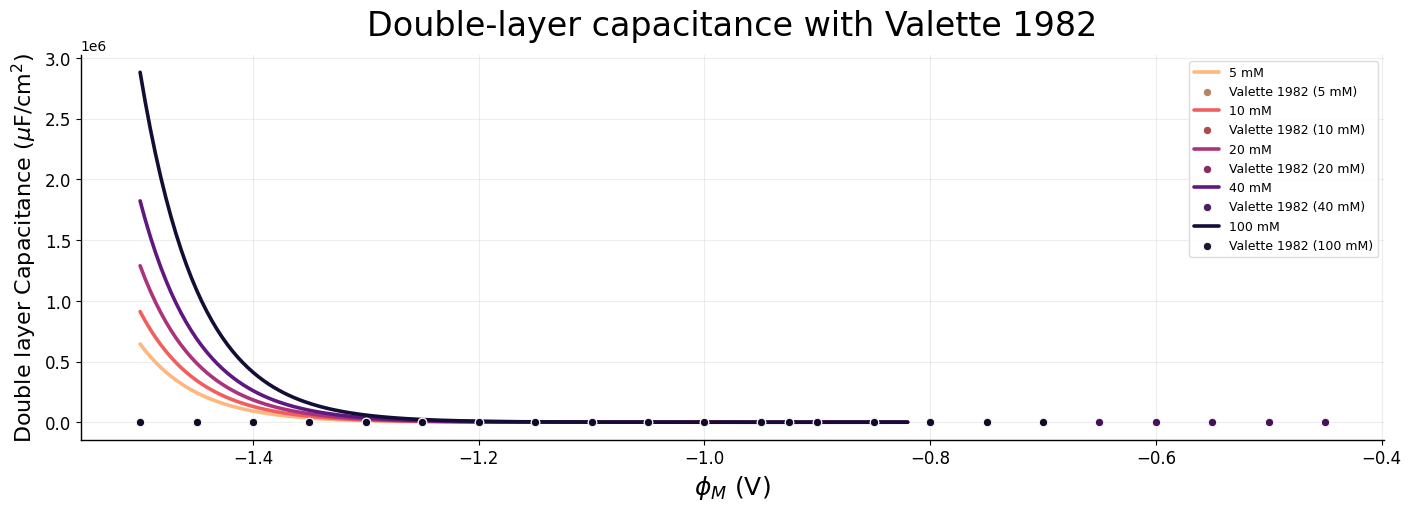

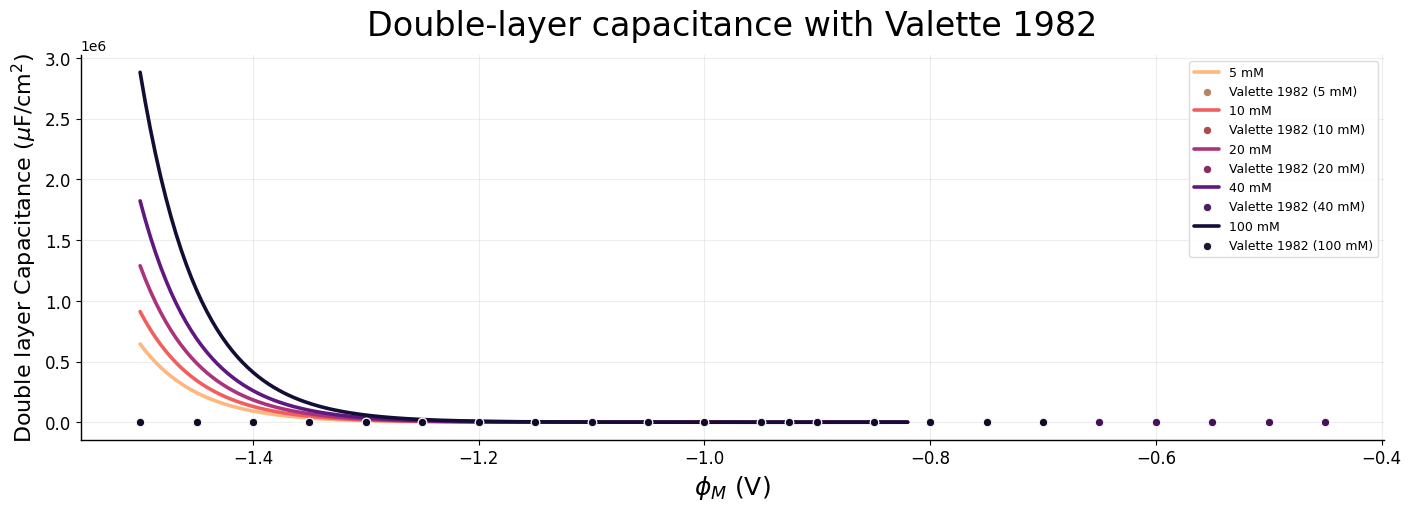

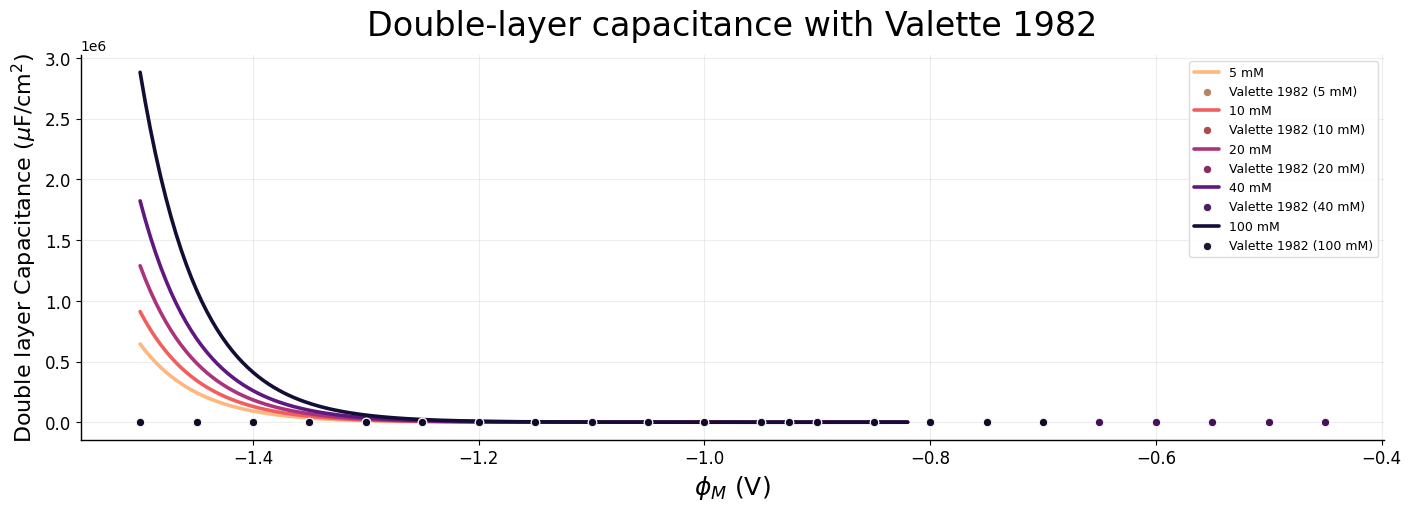

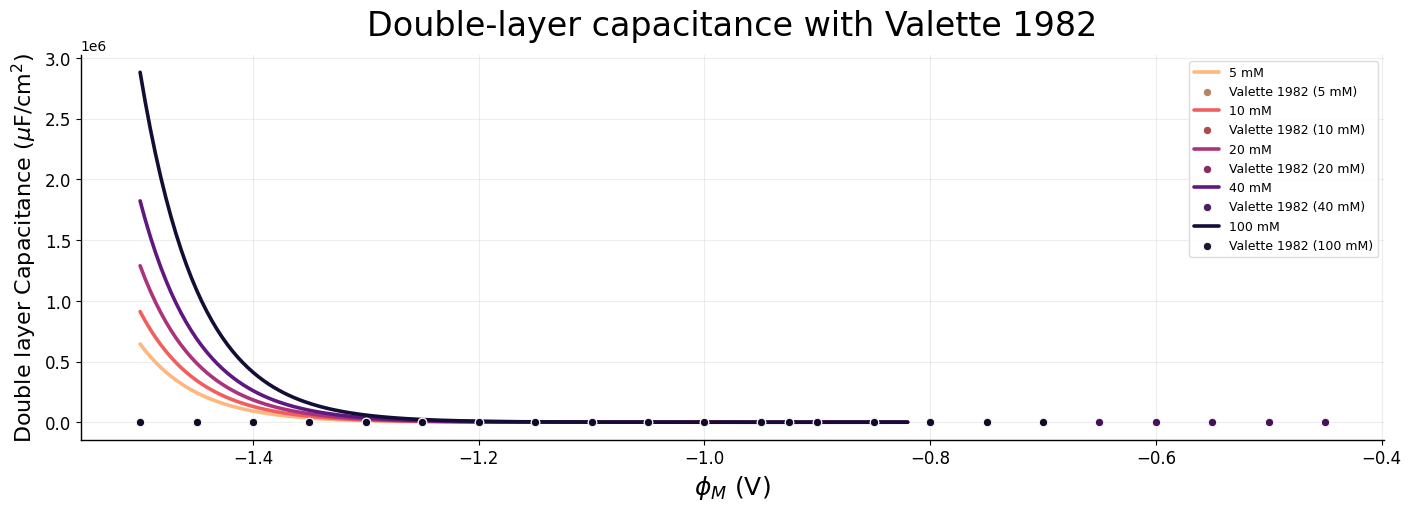

In [9]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

# =========================================================
# UI HELPERS
# =========================================================

LABEL_WIDTH = "170px"
BOX_WIDTH = "140px"

def make_row(label_html, widget, fontsize="16px"):
    widget.layout = widgets.Layout(width=BOX_WIDTH)

    label = widgets.HTML(
        value=f"""
        <span style="font-size:{fontsize}; line-height:1.2;">
            {label_html}
        </span>
        """,
        layout=widgets.Layout(width=LABEL_WIDTH)
    )

    return widgets.HBox(
        [label, widget],
        layout=widgets.Layout(align_items="center")
    )

def show_error(message):
    display(widgets.HTML(
        f"""
        <div style="
            color: #842029;
            background-color: #f8d7da;
            border: 1px solid #f5c2c7;
            border-radius: 6px;
            padding: 10px 12px;
            margin-top: 8px;
            font-weight: 500;
        ">
            {message}
        </div>
        """
    ))

# =========================================================
# WIDGETS
# =========================================================

valette_T_box = widgets.FloatText(value=298.15)
valette_T_row = make_row("T (K):", valette_T_box)

valette_eps_box = widgets.FloatText(value=78.5)
valette_eps_row = make_row("ε<sub>r</sub>:", valette_eps_box)

valette_phi_pzc_box = widgets.FloatText(value=-0.92)
valette_phi_pzc_row = make_row("φ<sub>pzc</sub> (V):", valette_phi_pzc_box)

valette_E_min_box = widgets.FloatText(value=-1.02)
valette_E_min_row = make_row("φ<sub>min</sub> (V):", valette_E_min_box)

valette_E_max_box = widgets.FloatText(value=-0.82)
valette_E_max_row = make_row("φ<sub>max</sub> (V):", valette_E_max_box)

valette_plot_button = widgets.Button(
    description="Plot",
    button_style="success",
    layout=widgets.Layout(width="120px")
)

valette_plot_row = widgets.HBox(
    [widgets.HTML(layout=widgets.Layout(width=LABEL_WIDTH)), valette_plot_button]
)

valette_out = widgets.Output(
    layout=widgets.Layout(width="auto", border="none")
)

# =========================================================
# CALLBACK
# =========================================================

def on_valette_plot_clicked(b):
    with valette_out:
        clear_output(wait=True)
        try:
            concentrations = [5.0, 10.0, 20.0, 40.0, 100.0]

            if valette_T_box.value <= 0:
                raise ValueError("Temperature must be > 0 K.")
            if valette_eps_box.value <= 0:
                raise ValueError("Relative permittivity must be > 0.")
            if valette_E_min_box.value >= valette_E_max_box.value:
                raise ValueError("E min must be smaller than E max.")

            plot_gc_capacitance_only(
                input_name="Concentration",
                input_values=concentrations,
                base_concentration=10.0,
                base_temperature=valette_T_box.value,
                base_dielectric=valette_eps_box.value,
                phi_pzc=valette_phi_pzc_box.value,
                E_min=valette_E_min_box.value,
                E_max=valette_E_max_box.value,
                npts=300
            )

        except ValueError as err:
            plt.close("all")
            clear_output(wait=True)
            show_error(f"Invalid input: {err}")

        except Exception as err:
            plt.close("all")
            clear_output(wait=True)
            show_error(f"Unexpected error: {err}")

valette_plot_button.on_click(on_valette_plot_clicked)

# =========================================================
# LAYOUT
# =========================================================

valette_controls = widgets.VBox(
    [
        valette_T_row,
        valette_eps_row,
        valette_phi_pzc_row,
        valette_E_min_row,
        valette_E_max_row,
        valette_plot_row,
    ],
    layout=widgets.Layout(width="360px", min_width="360px")
)

valette_output_panel = widgets.Box(
    [valette_out],
    layout=widgets.Layout(flex="1 1 0%", width="auto")
)

valette_ui = widgets.HBox(
    [valette_controls, valette_output_panel],
    layout=widgets.Layout(width="100%", align_items="flex-start")
)

display(valette_ui)